In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.colors import PowerNorm

### MUESTRA DE DATOS

# 100K DATASET

In [23]:

#100K
users_1M = pd.read_csv('BBDD_1M/users.dat', delimiter='::', engine='python', header=None, names=['userId', 'gender', 'age', 'occupation', 'zip'], encoding='ISO-8859-1')
movies_1M = pd.read_csv('BBDD_1M/movies.dat', delimiter='::', engine='python', header=None, names=['movieId', 'title', 'genres'], encoding='ISO-8859-1')
ratings_1M = pd.read_csv('BBDD_1M/ratings.dat', delimiter='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='ISO-8859-1')

In [24]:
print(movies_1M.head())
print(movies_1M.shape)
'''
movieId: ID de la película.
title: Título de la película, incluyendo el año.
genres: Lista de géneros separados por "|".
'''

   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
(3883, 3)


'\nmovieId: ID de la película.\ntitle: Título de la película, incluyendo el año.\ngenres: Lista de géneros separados por "|".\n'

Estos son los generos distintos que tenemos

In [25]:
unique_genres = set('|'.join(movies_1M['genres']).split('|'))
# Mostrar géneros únicos
print(unique_genres)

{'Film-Noir', 'Action', 'Sci-Fi', 'Documentary', 'Adventure', 'Romance', 'Crime', 'Drama', 'Animation', 'Fantasy', 'War', 'Musical', 'Western', 'Thriller', "Children's", 'Horror', 'Comedy', 'Mystery'}


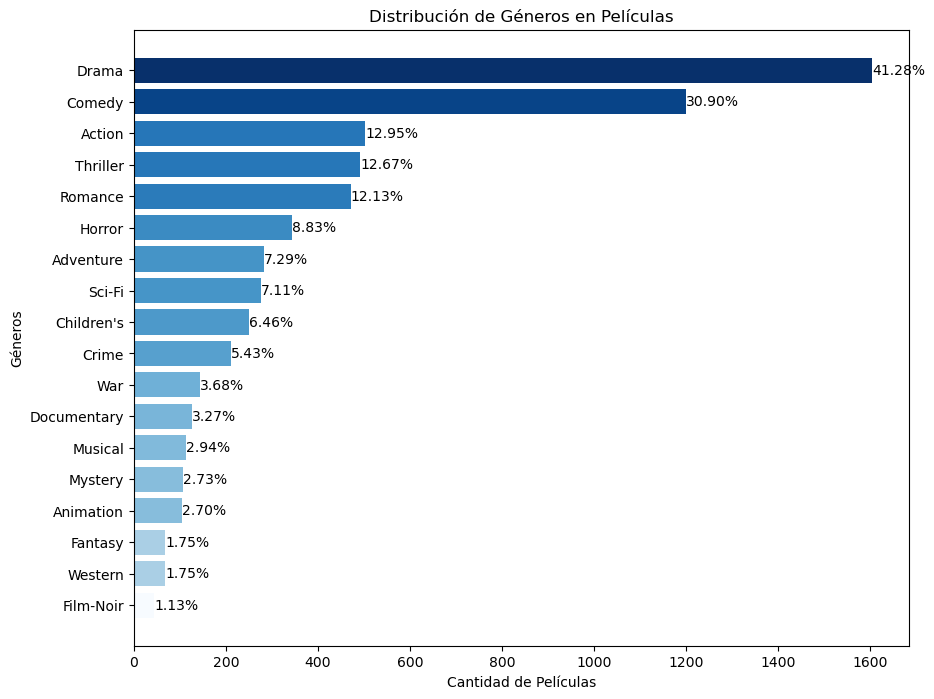

In [26]:
df = pd.concat([movies_1M], ignore_index=True).head(9742)

# Dividimos los géneros y los contamos
df['genres'] = df['genres'].str.split('|')
genre_count = df.explode('genres')['genres'].value_counts()

# Calculamos los porcentajes
genre_percentage = (genre_count / len(df)) * 100

# Graficamos
plt.figure(figsize=(10, 8))
norm = PowerNorm(gamma=0.26, vmin=min(genre_count), vmax=max(genre_count))
colors = plt.cm.Blues(norm(genre_count))
bars = plt.barh(genre_percentage.index, genre_count, color=colors)

# Añadimos las etiquetas con el porcentaje en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{(width/len(df))*100:.2f}%', va='center')

# Configuración de ejes y título
plt.xlabel('Cantidad de Películas')
plt.ylabel('Géneros')
plt.title('Distribución de Géneros en Películas')
plt.gca().invert_yaxis()  # Descendente
plt.show()

In [27]:
print(users_1M.head())
print(users_1M.shape)
'''
userId: ID del usuario.
movieId: ID de la película.
rating: Calificación de la película en una escala de 0.5 a 5.0.
timestamp: Momento en que se hizo la calificación.
'''

   userId gender  age  occupation    zip
0       1      F    1          10  48067
1       2      M   56          16  70072
2       3      M   25          15  55117
3       4      M   45           7  02460
4       5      M   25          20  55455
(6040, 5)


'\nuserId: ID del usuario.\nmovieId: ID de la película.\nrating: Calificación de la película en una escala de 0.5 a 5.0.\ntimestamp: Momento en que se hizo la calificación.\n'

In [28]:
print(ratings_1M.head())
print(ratings_1M.shape)
'''
userId: ID del usuario.
movieId: ID de la película.
tag: Etiqueta asignada.
timestamp: Momento en que se añadió la etiqueta.
'''

   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
(1000209, 4)


'\nuserId: ID del usuario.\nmovieId: ID de la película.\ntag: Etiqueta asignada.\ntimestamp: Momento en que se añadió la etiqueta.\n'

### DATOS CONCRETOS

In [29]:
df_1M = ratings_1M.copy()
df_1M.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Cuantos usuarios, peliculas y ratings tenemos?

Usuarios

In [30]:
df_1M['userId'].unique()

array([   1,    2,    3, ..., 6038, 6039, 6040], dtype=int64)

6040 usuarios en total

In [31]:
len(df_1M['userId'].unique())

6040

Cuantas películas tenemos?

In [32]:
df_1M['movieId'].unique()

array([1193,  661,  914, ..., 2845, 3607, 2909], dtype=int64)

3706 películas en total 

In [33]:
len(df_1M['movieId'].unique())

3706

In [34]:
df_1M['rating'].head()

0    5
1    3
2    3
3    4
4    5
Name: rating, dtype: int64

Las valoraciones van desde los 1 a 5

In [35]:
print("Min rating = "+str(df_1M['rating'].min()))
print("Max rating = "+str(df_1M['rating'].max()))

Min rating = 1
Max rating = 5


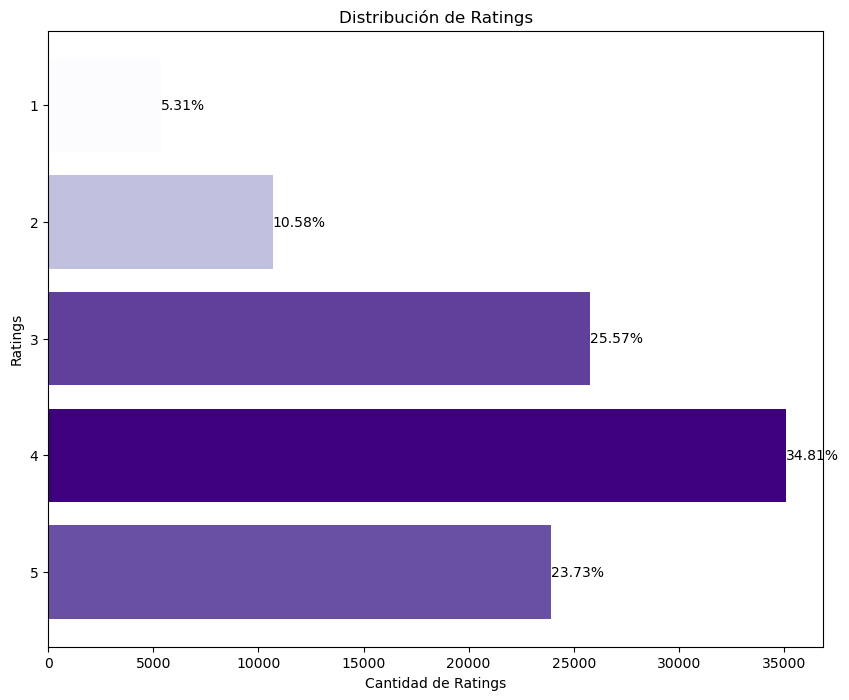

In [36]:
df_ratings = pd.concat([ratings_1M], ignore_index=True).head(100836)

# Contamos cuántas veces aparece cada rating
rating_count = df_ratings['rating'].value_counts().sort_index()

# Calculamos los porcentajes
rating_percentage = (rating_count / len(df_ratings)) * 100

# Configuramos el gradiente de color con PowerNorm
norm = PowerNorm(gamma=0.6, vmin=min(rating_count), vmax=max(rating_count))
colors = plt.cm.Purples(norm(rating_count))

# Graficamos con barras horizontales
plt.figure(figsize=(10, 8))
bars = plt.barh(rating_percentage.index, rating_count, color=colors)

# Añadimos las etiquetas con el porcentaje en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{(width/len(df_ratings))*100:.2f}%', va='center')

# Configuración de ejes y título
plt.xlabel('Cantidad de Ratings')
plt.ylabel('Ratings')
plt.title('Distribución de Ratings')
plt.gca().invert_yaxis()  # Descendente
plt.show()

El usuario que mas ratings ha puesto ha valorado 2314 películas, el que menos 20

In [37]:
ratings_count_per_user = df_1M.groupby('userId')['rating'].count()

max_ratings = ratings_count_per_user.max()
min_ratings = ratings_count_per_user.min()

print(f"Máximo de ratings por usuario: {max_ratings}")
print(f"Mínimo de ratings por usuario: {min_ratings}")

Máximo de ratings por usuario: 2314
Mínimo de ratings por usuario: 20


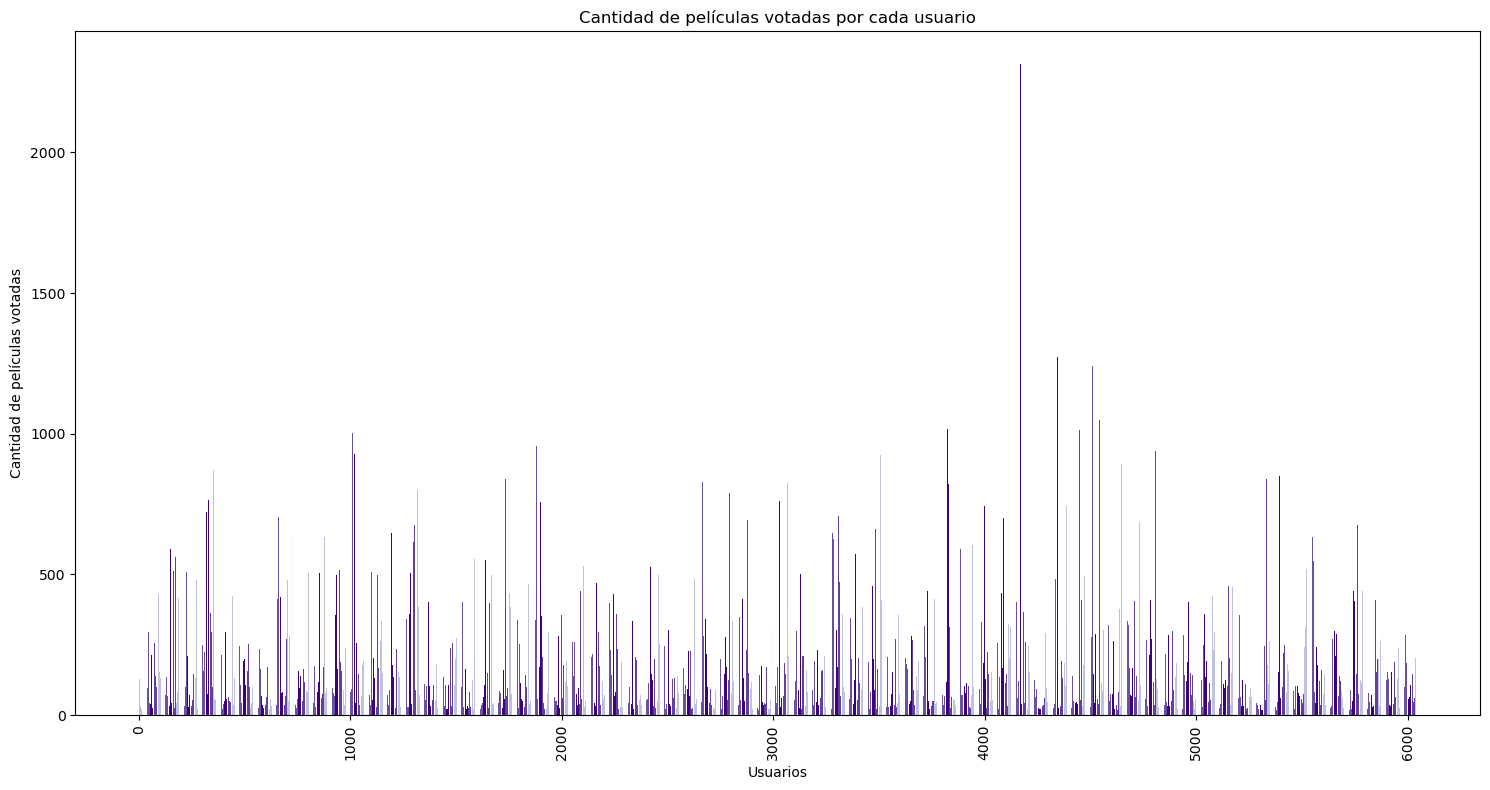

In [49]:
user_votes = df_1M.groupby('userId')['movieId'].count()

# Crear el gráfico de barras
plt.figure(figsize=(15, 8))
norm = PowerNorm(gamma=0.6, vmin=min(rating_count), vmax=max(rating_count))
colors = plt.cm.Purples(norm(rating_count))
plt.bar(user_votes.index, user_votes.values, color=colors)

# Añadir etiquetas y título
plt.xlabel('Usuarios')
plt.ylabel('Cantidad de películas votadas')
plt.title('Cantidad de películas votadas por cada usuario')

# Rotar etiquetas del eje X si hay muchos usuarios
plt.xticks(rotation=90)

# Mostrar gráfico
plt.tight_layout()  # Ajustar el layout para evitar solapamiento
plt.show()

In [56]:
user_votes = df_1M.groupby('userId')['movieId'].count()

# Calculamos la media
mean_votes_per_user = user_votes.mean()

print(f'El promedio de películas valoradas por los usuarios es: {mean_votes_per_user:.0f}')

El promedio de películas valoradas por los usuarios es: 166


1000209 valoraciones distintas

In [38]:
len(df_1M['rating'])

1000209

Tenemos valores nulos?

In [39]:
df_1M['userId'].isnull().sum()



0

In [40]:
df_1M['rating'].isnull().sum()

0

In [41]:
df_1M['movieId'].isnull().sum()

0

No hay valores nulos

### Pequeño resumen (BBDD 100K)

Tenemos una base de datos con 6040 usuarios y 3706 películas, donde cada usuario ha votado como minimo 20 películas y el que mas 2314, con un total de 1000209 valoraciones, sin valores nulos y con ratings que van desde 1 a 5 de puntuación.

## VISUALIZACIÓN DE LA ESCASEZ DE DATOS

Creación de la matriz de ratings de los usuarios sobre cada película

In [42]:
indice=list(df_1M['userId'].unique())
columnas=list(df_1M['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
escasez_1M=pd.pivot_table(data=df_1M,values='rating',index='userId',columns='movieId')

In [43]:
escasez_1M

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Contar el número total de NaN en la matriz de escasez
total_nan = escasez_1M.isna().sum().sum()

print(f"Número total de valores NaN: {total_nan}")


Número total de valores NaN: 21384031


En total tenemos 21.3M de valores NULOS en nuestra matriz

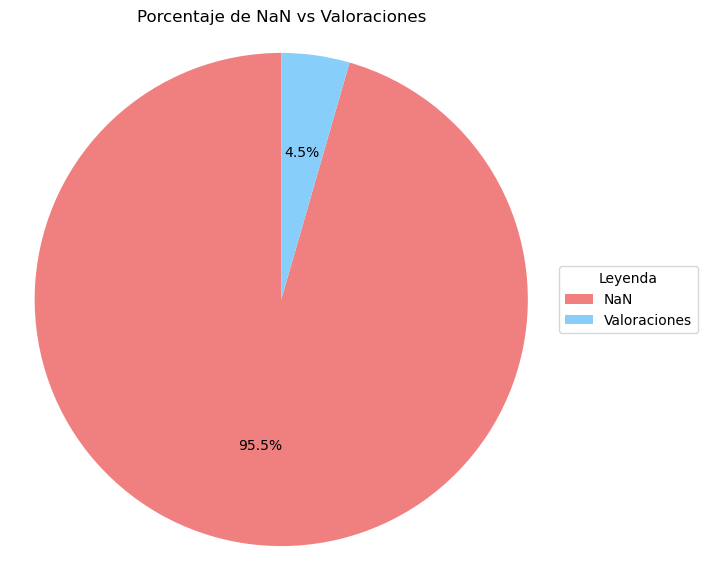

In [47]:
# Valores para el gráfico
total_valores = 6040 * 3706   # Tamaño total de la tabla (usuarios x películas)
total_valoraciones = total_valores - total_nan  # El resto son valoraciones válidas

# Porcentajes
labels = ['NaN', 'Valoraciones']
sizes = [total_nan, total_valoraciones]
colors = ['lightcoral', 'lightskyblue']  # Colores para el gráfico

# Crear el gráfico de pie (quesito)
plt.figure(figsize=(7, 7))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=colors)

# Añadir la leyenda
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), title="Leyenda")

plt.axis('equal')
plt.title('Porcentaje de NaN vs Valoraciones')

plt.show()

El porcentage de valores nulos es muy grande, habrá que transformarlos con factorización de matrices para estimar valores con los que se pueda trabajar.